# Лабораторная работа №1 — ЭТАЛОННОЕ РЕШЕНИЕ (Вариант 25)

## Компьютерная лексикография, TBX и Translation Memory (TMX) в Smartcat

**Предметная область варианта 25:** «Авиастроение и системы БПЛА: телеметрия, БАС и авионика».

**Состав работы:**

| Этап | Содержание | Баллы |
|------|------------|-------|
| 1 | Парсинг и валидация схемы TBX-глоссария | 2 |
| 2 | Извлечение пар сегментов из TMX памяти переводов | 2 |
| 3 | Алгоритм Fuzzy Match (75–99 %) и 100 % ICE | 3 |
| 4 | Интеграция глоссария: подстановка терминов при переводе | 2 |
| 5 | Оформление отчёта и репозитория | 1 |

> Ноутбук самодостаточен: он сам генерирует `variant_25.tbx` и `variant_25.tmx`,
> затем разбирает их, считает нечёткие совпадения и экспортирует CSV для Smartcat.

## Краткая теория: форматы данных в CAT-системах

В этой лабораторной работе рассматриваются три формата, которые решают **разные задачи** в процессе автоматизированного перевода. Важно не смешивать терминологическую базу и память переводов: они дополняют друг друга, но хранят данные разного уровня.

| Формат | Что хранит | Типичная единица данных | Где используется в работе |
|---|---|---|---|
| **TBX (TermBase eXchange)** | термины, их переводы, грамматические и предметные сведения | терминологическая запись / понятие | создание и разбор глоссария |
| **TMX (Translation Memory eXchange)** | уже переведённые пары сегментов | исходный сегмент + перевод | память переводов и поиск совпадений |
| **CSV (Comma-Separated Values)** | плоские табличные данные | строка таблицы | обмен с Smartcat и подготовка отчётов |

### TBX
**TBX** — XML-формат обмена терминологическими базами. Его задача — обеспечить единообразие терминологии. Одна терминологическая запись описывает понятие, а внутри неё могут храниться варианты термина на разных языках, часть речи, определение и предметная область. Для педагога это удобный пример **структурированных лингвистических данных**: один объект реального мира представляется набором связанных атрибутов.

### TMX
**TMX** — XML-формат обмена памятью переводов. В отличие от TBX он работает не с отдельными терминами, а с **целыми сегментами** текста. Основной объект — единица перевода `tu`, внутри которой находятся языковые варианты `tuv` и текст сегмента `seg`. TMX позволяет повторно использовать ранее выполненные переводы и является основой для Exact Match и Fuzzy Match.

### CSV
**CSV** — простой табличный формат обмена данными. Он не описывает сложную иерархию, как XML, зато легко открывается в электронных таблицах и импортируется в прикладные системы. В работе CSV используется как практический формат экспорта глоссария и отчётов.

### Почему TBX и TMX основаны на XML
XML хранит данные в виде иерархии тегов и атрибутов. Это удобно, когда необходимо передавать не только текст, но и его структуру: язык, идентификаторы, предметную область, свойства терминов и сегментов. В Python XML разбирается в дерево элементов, после чего программа может находить нужные узлы и преобразовывать их в таблицы `pandas`.

> **Ключевая идея лабораторной:** TBX отвечает на вопрос «**какие термины использовать?**», TMX — «**переводили ли мы похожее раньше?**», а CSV — «**как удобно передать результат в другую систему или отчёт?**».


## Блок 0. Установка зависимостей

В Google Colab `pandas`, `lxml` и `matplotlib` предустановлены; отдельно ставится
только быстрая C-реализация расстояния Левенштейна.

### Пояснение к блоку 0

**Что делает блок.** Устанавливает внешние библиотеки, необходимые для работы с XML, таблицами и расстоянием Левенштейна.

**Зачем это нужно.** Лабораторная объединяет несколько типов обработки данных: XML-файлы TBX/TMX, табличные структуры `pandas` и алгоритм строкового сходства. Поэтому до выполнения основного кода среда должна содержать соответствующие пакеты.

**На что обратить внимание студентам.** Команда начинается с `!`, потому что в Jupyter/Colab так запускается системная команда оболочки. Параметр `-q` уменьшает объём служебного вывода установки.

**Результат блока.** После выполнения среда готова к запуску остальных ячеек ноутбука.


In [1]:
!pip install -q Levenshtein lxml pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.7/158.7 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 16.6 MB/s eta 0:00:00


## Блок 1. Импорты и настройка окружения

Код написан так, чтобы работать и с библиотекой `Levenshtein` (C-расширение),
и без неё — на чистой Python-реализации матрицы редактирования.
То же самое сделано для XML: приоритет у `lxml`, запасной вариант —
`xml.etree.ElementTree` из стандартной библиотеки.

### Пояснение к блоку 1

**Что делает блок.** Подключает стандартные и внешние библиотеки, определяет XML-парсер, выбирает реализацию расстояния Левенштейна и задаёт общие параметры среды.

**Логика блока.** Код использует принцип *fallback*: сначала пытается подключить более производительные библиотеки (`lxml`, `Levenshtein`), а при их отсутствии переключается на стандартные средства Python или собственную реализацию. Это делает ноутбук переносимым.

**Что важно увидеть в коде.**
- `try/except ImportError` — обработка ситуации, когда библиотека не установлена;
- `XML_LANG` — полное имя атрибута `xml:lang` с пространством имён XML;
- `indent_tree()` — служебная функция для красивого форматирования XML;
- `pd.set_option(...)` — настройка отображения таблиц, а не изменение самих данных.

**Результат блока.** В выводе видно, какой XML-движок и какой алгоритм Левенштейна реально используются, а также текущий рабочий каталог.

**Педагогический акцент.** Это хороший пример разработки кода, который устойчив к различиям программной среды: студент видит не только алгоритм, но и инженерный подход к совместимости.


In [2]:
from __future__ import annotations

import csv
import os
import re
import unicodedata
from datetime import datetime, timezone
from typing import Any, Dict, Iterable, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import pandas as pd

# --- XML backend -----------------------------------------------------------
try:
    from lxml import etree as ET

    LXML_AVAILABLE = True
except ImportError:  # pragma: no cover - fallback для «голого» окружения
    import xml.etree.ElementTree as ET

    LXML_AVAILABLE = False

# --- Levenshtein backend ---------------------------------------------------
try:
    import Levenshtein as _lev

    def edit_distance(a: str, b: str) -> int:
        """Расстояние Левенштейна (C-реализация)."""
        return _lev.distance(a, b)

    LEV_BACKEND = "Levenshtein (C)"
except ImportError:  # pragma: no cover

    def edit_distance(a: str, b: str) -> int:
        """Расстояние Левенштейна (чистый Python, O(n*m) время, O(m) память)."""
        if a == b:
            return 0
        if not a:
            return len(b)
        if not b:
            return len(a)
        previous: List[int] = list(range(len(b) + 1))
        for i, char_a in enumerate(a, start=1):
            current: List[int] = [i]
            for j, char_b in enumerate(b, start=1):
                current.append(
                    min(
                        previous[j] + 1,          # удаление
                        current[j - 1] + 1,       # вставка
                        previous[j - 1] + (char_a != char_b),  # замена
                    )
                )
            previous = current
        return previous[-1]

    LEV_BACKEND = "pure-python fallback"

XML_LANG = "{http://www.w3.org/XML/1998/namespace}lang"
WORK_DIR = os.getcwd()


def indent_tree(element, level: int = 0, space: str = "  ") -> None:
    """Рекурсивно расставить отступы в XML-дереве (работает и с lxml, и с ET)."""
    pad = "\n" + space * level
    if len(element):
        if not (element.text or "").strip():
            element.text = pad + space
        for child in element:
            indent_tree(child, level + 1, space)
        if not (element.tail or "").strip():
            element.tail = pad
        if not (element[-1].tail or "").strip():
            element[-1].tail = pad
    elif level and not (element.tail or "").strip():
        element.tail = pad

pd.set_option("display.max_colwidth", 46)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 200)

print(f"XML backend        : {'lxml' if LXML_AVAILABLE else 'xml.etree.ElementTree'}")
print(f"Levenshtein backend: {LEV_BACKEND}")
print(f"pandas             : {pd.__version__}")
print(f"Рабочий каталог    : {WORK_DIR}")

XML backend        : lxml
Levenshtein backend: Levenshtein (C)
pandas             : 2.2.3
Рабочий каталог    : /content


## Блок 2. Генерация терминологической базы `variant_25.tbx`

Структура TBX (ISO 30042, ядро TBX-Core v2):

```
martif
└── martifHeader / fileDesc / titleStmt / title
└── text
    └── body
        └── termEntry              (одно понятие)
            ├── descrip[subjectField]
            └── langSet xml:lang   (одна секция на язык)
                ├── tig            (term + termNote)
                └── ntig/termGrp   (расширенный вариант записи)
```

В генераторе английские секции оформлены через `<tig>`, русские — через
`<ntig><termGrp>`: парсер обязан корректно обрабатывать оба варианта.

### Пояснение к блоку 2

**Что делает блок.** Из списка терминов `TERMS` программно создаёт полноценный файл `variant_25.tbx`.

**Как читать этот код.** Каждый словарь в `TERMS` описывает одну терминологическую единицу: английский термин, русский эквивалент, часть речи и определение. Функция `build_tbx()` преобразует эти плоские записи в иерархическую XML-структуру TBX.

**Ключевые элементы TBX в коде.**
- `termEntry` — одна понятийная статья;
- `langSet` — языковая секция;
- `term` — сам термин;
- `termNote` — дополнительная характеристика, здесь часть речи;
- `descrip` — описание, определение или предметная область.

**Почему используются две формы `tig` и `ntig/termGrp`.** Это намеренная демонстрация того, что один и тот же тип данных в TBX может иметь различное XML-представление. Следующий парсер должен быть достаточно универсальным, чтобы извлекать термины из обеих форм.

**Результат блока.** На диске появляется TBX-файл, после чего выводятся его первые строки. Студент может сопоставить Python-объекты с фактически созданными XML-тегами.

**Педагогический акцент.** Здесь удобно обсудить переход от табличного представления данных к иерархическому и показать, что формат файла — это не просто расширение, а формальная структура данных.


In [3]:
TERMS: List[Dict[str, str]] = [
    {"en": "flight controller", "ru": "полётный контроллер", "pos": "noun",
     "def_en": "Onboard computer that stabilises the aircraft and executes the flight plan."},
    {"en": "uncrewed aircraft system", "ru": "беспилотная авиационная система", "pos": "noun",
     "def_en": "Aircraft, ground control station, datalink and crew considered as one system."},
    {"en": "payload", "ru": "целевая нагрузка", "pos": "noun",
     "def_en": "Equipment carried to perform the mission (camera, lidar, radio relay)."},
    {"en": "telemetry link", "ru": "канал телеметрии", "pos": "noun",
     "def_en": "Radio channel transmitting aircraft state data to the ground station."},
    {"en": "pitot tube", "ru": "приёмник воздушного давления", "pos": "noun",
     "def_en": "Sensor measuring total pressure to derive indicated airspeed."},
    {"en": "ground control station", "ru": "наземная станция управления", "pos": "noun",
     "def_en": "Hardware and software complex used by the operator to control the flight."},
    {"en": "avionics", "ru": "авионика", "pos": "noun",
     "def_en": "Set of onboard electronic systems of an aircraft."},
    {"en": "airframe", "ru": "планёр", "pos": "noun",
     "def_en": "Load-bearing structure of the aircraft without engines and payload."},
    {"en": "inertial measurement unit", "ru": "инерциальный измерительный блок", "pos": "noun",
     "def_en": "Assembly of accelerometers and gyroscopes measuring attitude and accelerations."},
    {"en": "angle of attack", "ru": "угол атаки", "pos": "noun",
     "def_en": "Angle between the chord of the wing and the oncoming airflow."},
    {"en": "waypoint", "ru": "путевая точка", "pos": "noun",
     "def_en": "Reference point of the route defined by coordinates and altitude."},
    {"en": "gimbal", "ru": "гиростабилизированный подвес", "pos": "noun",
     "def_en": "Stabilised mount that keeps the payload orientation independent of airframe motion."},
    {"en": "beyond visual line of sight", "ru": "полёт вне зоны прямой видимости", "pos": "noun",
     "def_en": "Operation mode in which the aircraft is out of the operator's direct sight."},
    {"en": "autopilot", "ru": "автопилот", "pos": "noun",
     "def_en": "Subsystem maintaining the assigned flight parameters without operator input."},
    {"en": "barometric altimeter", "ru": "барометрический высотомер", "pos": "noun",
     "def_en": "Instrument deriving altitude from static air pressure."},
    {"en": "thrust-to-weight ratio", "ru": "тяговооружённость", "pos": "noun",
     "def_en": "Ratio of available thrust to the take-off weight of the aircraft."},
    {"en": "failsafe", "ru": "режим аварийного возврата", "pos": "noun",
     "def_en": "Automatic scenario triggered on datalink loss or low battery."},
    {"en": "propeller pitch", "ru": "шаг воздушного винта", "pos": "noun",
     "def_en": "Distance a propeller advances per revolution in a solid medium."},
]

SUBJECT_FIELD = "Авиастроение и беспилотные авиационные системы"
TBX_PATH = "variant_25.tbx"


def build_tbx(terms: Sequence[Dict[str, str]], path: str,
              subject_field: str = SUBJECT_FIELD) -> str:
    """Сгенерировать валидный TBX-файл (TBX-Core v2, martif).

    Args:
        terms: последовательность словарей с ключами ``en``, ``ru``, ``pos``, ``def_en``.
        path: путь к создаваемому файлу.
        subject_field: предметная область, записывается в ``descrip[subjectField]``.

    Returns:
        Путь к созданному файлу.
    """
    martif = ET.Element("martif", {"type": "TBX", XML_LANG: "en"})

    header = ET.SubElement(martif, "martifHeader")
    file_desc = ET.SubElement(header, "fileDesc")
    title_stmt = ET.SubElement(file_desc, "titleStmt")
    ET.SubElement(title_stmt, "title").text = f"Glossary EN-RU: {subject_field}"
    source_desc = ET.SubElement(file_desc, "sourceDesc")
    ET.SubElement(source_desc, "p").text = "Lab 01, variant 25, generated automatically"
    encoding_desc = ET.SubElement(header, "encodingDesc")
    ET.SubElement(encoding_desc, "p", {"type": "XCSURI"}).text = "TBXXCSV02.xcs"

    body = ET.SubElement(ET.SubElement(martif, "text"), "body")

    for index, item in enumerate(terms, start=1):
        entry = ET.SubElement(body, "termEntry", {"id": f"tid-{index:03d}"})
        ET.SubElement(entry, "descrip", {"type": "subjectField"}).text = subject_field

        # --- английская секция: краткая форма <tig> ---
        lang_en = ET.SubElement(entry, "langSet", {XML_LANG: "en"})
        tig = ET.SubElement(lang_en, "tig")
        ET.SubElement(tig, "term").text = item["en"]
        ET.SubElement(tig, "termNote", {"type": "partOfSpeech"}).text = item["pos"]
        ET.SubElement(tig, "descrip", {"type": "definition"}).text = item["def_en"]

        # --- русская секция: расширенная форма <ntig><termGrp> ---
        lang_ru = ET.SubElement(entry, "langSet", {XML_LANG: "ru"})
        term_grp = ET.SubElement(ET.SubElement(lang_ru, "ntig"), "termGrp")
        ET.SubElement(term_grp, "term").text = item["ru"]
        ET.SubElement(term_grp, "termNote", {"type": "partOfSpeech"}).text = item["pos"]

    indent_tree(martif)
    xml_body = ET.tostring(martif, encoding="unicode")
    with open(path, "w", encoding="utf-8") as handler:
        handler.write('<?xml version="1.0" encoding="UTF-8"?>\n')
        handler.write('<!DOCTYPE martif SYSTEM "TBXcoreStructV02.dtd">\n')
        handler.write(xml_body)
    return path


build_tbx(TERMS, TBX_PATH)
print(f"Создан {TBX_PATH}: {os.path.getsize(TBX_PATH)} байт, терминов: {len(TERMS)}\n")
print("--- первые 26 строк файла ---")
with open(TBX_PATH, encoding="utf-8") as handler:
    for line in list(handler)[:26]:
        print(line.rstrip())

Создан variant_25.tbx: 13981 байт, терминов: 18

--- первые 26 строк файла ---
<?xml version="1.0" encoding="UTF-8"?>
<!DOCTYPE martif SYSTEM "TBXcoreStructV02.dtd">
<martif type="TBX" xml:lang="en">
  <martifHeader>
    <fileDesc>
      <titleStmt>
        <title>Glossary EN-RU: Авиастроение и беспилотные авиационные системы</title>
      </titleStmt>
      <sourceDesc>
        <p>Lab 01, variant 25, generated automatically</p>
      </sourceDesc>
    </fileDesc>
    <encodingDesc>
      <p type="XCSURI">TBXXCSV02.xcs</p>
    </encodingDesc>
  </martifHeader>
  <text>
    <body>
      <termEntry id="tid-001">
        <descrip type="subjectField">Авиастроение и беспилотные авиационные системы</descrip>
        <langSet xml:lang="en">
          <tig>
            <term>flight controller</term>
            <termNote type="partOfSpeech">noun</termNote>
            <descrip type="definition">Onboard computer that stabilises the aircraft and executes the flight plan.</descrip>
          </ti

## Блок 3. Генерация памяти переводов `variant_25.tmx`

Структура TMX 1.4b:

```
tmx version="1.4"
├── header  (creationtool, segtype, srclang, adminlang, datatype …)
└── body
    └── tu tuid                (единица перевода)
        ├── prop[domain]
        └── tuv xml:lang       (вариант на конкретном языке)
            └── seg            (текст сегмента)
```

Порядок `<tu>` внутри `<body>` сохраняется — он нужен для контекстного
сопоставления (ICE, In-Context Exact Match).

### Пояснение к блоку 3

**Что делает блок.** Создаёт тестовую память переводов `variant_25.tmx` из параллельного корпуса английских и русских предложений.

**Как организованы данные.** `PARALLEL_CORPUS` содержит пары `(исходный сегмент, перевод)`. Для каждой пары создаётся `tu` — единица перевода, а внутри неё две секции `tuv` с языками `en` и `ru`. Текст помещается в `seg`.

**Зачем нужен `tuid`.** Это идентификатор единицы перевода. Он позволяет однозначно ссылаться на конкретную пару сегментов и отслеживать её в отчётах.

**Зачем хранится порядок `tu`.** Далее он используется как упрощённая модель контекста: предыдущий сегмент помогает отличить обычное точное совпадение от контекстного ICE.

**Результат блока.** Создаётся TMX-файл и выводится его начало. Таким образом можно визуально сравнить структуру TMX со структурой TBX и увидеть, что оба формата XML-подобны, но описывают разные сущности.


In [4]:
PARALLEL_CORPUS: List[Tuple[str, str]] = [
    ("The flight controller stabilises the airframe during autonomous flight.",
     "Полётный контроллер стабилизирует планёр во время автономного полёта."),
    ("Before take-off the operator checks the telemetry link quality.",
     "Перед взлётом оператор проверяет качество канала телеметрии."),
    ("The uncrewed aircraft system includes the ground control station and the datalink.",
     "Беспилотная авиационная система включает наземную станцию управления и линию передачи данных."),
    ("The payload is mounted on a stabilised gimbal under the fuselage.",
     "Целевая нагрузка устанавливается на гиростабилизированный подвес под фюзеляжем."),
    ("A blocked pitot tube causes incorrect indicated airspeed readings.",
     "Засорённый приёмник воздушного давления приводит к неверным показаниям приборной скорости."),
    ("The inertial measurement unit provides attitude data at 200 Hz.",
     "Инерциальный измерительный блок выдаёт данные об угловом положении с частотой 200 Гц."),
    ("Exceeding the critical angle of attack leads to a stall.",
     "Превышение критического угла атаки приводит к сваливанию."),
    ("The operator uploads a new waypoint to the autopilot.",
     "Оператор загружает новую путевую точку в автопилот."),
    ("On datalink loss the failsafe returns the aircraft to the launch point.",
     "При потере линии передачи данных режим аварийного возврата приводит аппарат в точку старта."),
    ("Beyond visual line of sight operations require an additional flight permit.",
     "Полёты вне зоны прямой видимости требуют дополнительного разрешения на выполнение полёта."),
    ("The barometric altimeter is calibrated to the airfield pressure before the flight.",
     "Барометрический высотомер калибруется по давлению аэродрома перед полётом."),
    ("A high thrust-to-weight ratio shortens the take-off run of the aircraft.",
     "Высокая тяговооружённость сокращает длину разбега аппарата."),
    ("The avionics bay is cooled by a dedicated air duct.",
     "Отсек авионики охлаждается отдельным воздушным каналом."),
    ("Increasing the propeller pitch reduces the rotation speed at constant thrust.",
     "Увеличение шага воздушного винта снижает частоту вращения при постоянной тяге."),
]

TMX_PATH = "variant_25.tmx"


def build_tmx(pairs: Sequence[Tuple[str, str]], path: str,
              src_lang: str = "en", tgt_lang: str = "ru",
              domain: str = "Aerospace / UAS") -> str:
    """Сгенерировать валидную память переводов в формате TMX 1.4b.

    Args:
        pairs: последовательность кортежей ``(текст_источника, текст_перевода)``.
        path: путь к создаваемому файлу.
        src_lang: код языка оригинала (атрибут ``srclang`` заголовка).
        tgt_lang: код языка перевода.
        domain: значение свойства ``prop[type="domain"]``.

    Returns:
        Путь к созданному файлу.
    """
    created = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")

    tmx = ET.Element("tmx", {"version": "1.4"})
    ET.SubElement(tmx, "header", {
        "creationtool": "lab01-generator",
        "creationtoolversion": "1.0",
        "segtype": "sentence",
        "o-tmf": "TMX",
        "adminlang": "en",
        "srclang": src_lang,
        "datatype": "plaintext",
        "creationdate": created,
    })
    body = ET.SubElement(tmx, "body")

    for index, (source, target) in enumerate(pairs, start=1):
        tu = ET.SubElement(body, "tu", {"tuid": str(index), "creationdate": created})
        ET.SubElement(tu, "prop", {"type": "domain"}).text = domain
        for lang, text in ((src_lang, source), (tgt_lang, target)):
            tuv = ET.SubElement(tu, "tuv", {XML_LANG: lang})
            ET.SubElement(tuv, "seg").text = text

    indent_tree(tmx)
    xml_body = ET.tostring(tmx, encoding="unicode")
    with open(path, "w", encoding="utf-8") as handler:
        handler.write('<?xml version="1.0" encoding="UTF-8"?>\n')
        handler.write('<!DOCTYPE tmx SYSTEM "tmx14.dtd">\n')
        handler.write(xml_body)
    return path


build_tmx(PARALLEL_CORPUS, TMX_PATH)
print(f"Создан {TMX_PATH}: {os.path.getsize(TMX_PATH)} байт, единиц перевода: {len(PARALLEL_CORPUS)}\n")
print("--- первые 20 строк файла ---")
with open(TMX_PATH, encoding="utf-8") as handler:
    for line in list(handler)[:20]:
        print(line.rstrip())

Создан variant_25.tmx: 6363 байт, единиц перевода: 14

--- первые 20 строк файла ---
<?xml version="1.0" encoding="UTF-8"?>
<!DOCTYPE tmx SYSTEM "tmx14.dtd">
<tmx version="1.4">
  <header creationtool="lab01-generator" creationtoolversion="1.0" segtype="sentence" o-tmf="TMX" adminlang="en" srclang="en" datatype="plaintext" creationdate="20260908T113635Z"/>
  <body>
    <tu tuid="1" creationdate="20260908T113635Z">
      <prop type="domain">Aerospace / UAS</prop>
      <tuv xml:lang="en">
        <seg>The flight controller stabilises the airframe during autonomous flight.</seg>
      </tuv>
      <tuv xml:lang="ru">
        <seg>Полётный контроллер стабилизирует планёр во время автономного полёта.</seg>
      </tuv>
    </tu>
    <tu tuid="2" creationdate="20260908T113635Z">
      <prop type="domain">Aerospace / UAS</prop>
      <tuv xml:lang="en">
        <seg>Before take-off the operator checks the telemetry link quality.</seg>
      </tuv>
      <tuv xml:lang="ru">


## Блок 4. Парсинг и валидация TBX (2 балла)

Ключевой момент — атрибут `xml:lang`, который в XML-парсерах раскрывается в
полное имя `{http://www.w3.org/XML/1998/namespace}lang`. Поиск `<term>` ведётся
через `langset.iter("term")`, что покрывает и `tig`, и `ntig/termGrp`.

### Пояснение к блоку 4

**Что делает блок.** Сначала проверяет корректность структуры TBX, затем извлекает терминологические записи и переводит их в таблицу `pandas.DataFrame`.

**Почему валидация выполняется отдельно от парсинга.** Валидация отвечает на вопрос «соответствует ли файл ожидаемой структуре?», а парсинг — «какие данные из него нужно получить?». Такое разделение повышает надёжность обработки внешних файлов.

**Что проверяется.** Корневой элемент, наличие заголовка и тела, количество языковых секций, атрибут `xml:lang`, наличие непустых терминов. Ошибки накапливаются в списке, поэтому пользователь получает отчёт, а не только аварийное завершение программы.

**Что получается после `parse_tbx()`.** Иерархическая XML-структура преобразуется в обычную таблицу: идентификатор статьи, исходный термин, перевод, часть речи, определение и предметная область. Это уже удобная форма для анализа, поиска и экспорта.

**Педагогический акцент.** Блок показывает типовой конвейер обработки данных: **получить файл → проверить структуру → извлечь данные → привести к аналитической таблице**. Этот шаблон переносится на многие задачи цифровой обработки образовательных и лингвистических данных.


In [5]:
def _parse_xml(path: str):
    """Безопасно разобрать XML-файл (без загрузки внешних DTD и сущностей)."""
    if LXML_AVAILABLE:
        parser = ET.XMLParser(resolve_entities=False, load_dtd=False, no_network=True)
        return ET.parse(path, parser)
    return ET.parse(path)


def validate_tbx(file_path: str) -> Dict[str, Any]:
    """Проверить структурную корректность TBX-файла.

    Проверяются: имя корневого элемента, наличие ``martifHeader``/``text``/``body``,
    наличие хотя бы двух ``langSet`` с непустым ``xml:lang`` в каждом ``termEntry``
    и наличие непустого ``<term>`` в каждой языковой секции.

    Args:
        file_path: путь к ``.tbx``-файлу.

    Returns:
        Словарь-отчёт с ключами ``valid`` (bool), ``errors`` (list[str]),
        ``entries`` (int), ``languages`` (list[str]).
    """
    errors: List[str] = []
    try:
        tree = _parse_xml(file_path)
    except Exception as exc:  # noqa: BLE001 - отчёт вместо аварийного завершения
        return {"valid": False, "errors": [f"XML не разобран: {exc}"],
                "entries": 0, "languages": []}

    root = tree.getroot()
    if root.tag != "martif":
        errors.append(f"Корневой элемент '{root.tag}', ожидается 'martif'")
    if root.find("martifHeader") is None:
        errors.append("Отсутствует секция <martifHeader>")

    body = root.find("./text/body")
    if body is None:
        errors.append("Отсутствует секция <text><body>")
        return {"valid": False, "errors": errors, "entries": 0, "languages": []}

    entries = body.findall("termEntry")
    if not entries:
        errors.append("В <body> нет ни одного <termEntry>")

    languages: List[str] = []
    for entry in entries:
        entry_id = entry.get("id", "<без id>")
        lang_sets = entry.findall("langSet")
        if len(lang_sets) < 2:
            errors.append(f"{entry_id}: языковых секций {len(lang_sets)}, нужно >= 2")
        for lang_set in lang_sets:
            lang = lang_set.get(XML_LANG)
            if not lang:
                errors.append(f"{entry_id}: у <langSet> нет атрибута xml:lang")
                continue
            if lang not in languages:
                languages.append(lang)
            terms = [t for t in lang_set.iter("term") if (t.text or "").strip()]
            if not terms:
                errors.append(f"{entry_id}/{lang}: нет непустого <term>")

    return {"valid": not errors, "errors": errors,
            "entries": len(entries), "languages": languages}


def parse_tbx(file_path: str, src_lang: str = "en", tgt_lang: str = "ru") -> pd.DataFrame:
    """Разобрать TBX-глоссарий в плоскую таблицу терминов.

    Args:
        file_path: путь к ``.tbx``-файлу.
        src_lang: код языка исходных терминов.
        tgt_lang: код языка переводных эквивалентов.

    Returns:
        ``pd.DataFrame`` с колонками ``entry_id``, ``source_term``, ``target_term``,
        ``pos``, ``definition``, ``subject_field``.
    """
    root = _parse_xml(file_path).getroot()
    rows: List[Dict[str, str]] = []

    for entry in root.iter("termEntry"):
        subject = ""
        descrip = entry.find("descrip[@type='subjectField']")
        if descrip is not None and descrip.text:
            subject = descrip.text.strip()

        by_lang: Dict[str, Dict[str, str]] = {}
        for lang_set in entry.findall("langSet"):
            lang = (lang_set.get(XML_LANG) or "").split("-")[0].lower()
            terms = [t.text.strip() for t in lang_set.iter("term") if (t.text or "").strip()]
            if not terms:
                continue
            note = lang_set.find(".//termNote[@type='partOfSpeech']")
            definition = lang_set.find(".//descrip[@type='definition']")
            by_lang[lang] = {
                "term": terms[0],
                "pos": (note.text or "").strip() if note is not None else "",
                "definition": (definition.text or "").strip() if definition is not None else "",
            }

        if src_lang in by_lang and tgt_lang in by_lang:
            rows.append({
                "entry_id": entry.get("id", ""),
                "source_term": by_lang[src_lang]["term"],
                "target_term": by_lang[tgt_lang]["term"],
                "pos": by_lang[src_lang]["pos"] or by_lang[tgt_lang]["pos"],
                "definition": by_lang[src_lang]["definition"],
                "subject_field": subject,
            })

    return pd.DataFrame(rows, columns=["entry_id", "source_term", "target_term",
                                       "pos", "definition", "subject_field"])


report = validate_tbx(TBX_PATH)
print("Валидация TBX")
print(f"  структура корректна : {report['valid']}")
print(f"  термостатей         : {report['entries']}")
print(f"  языки               : {report['languages']}")
print(f"  ошибок              : {len(report['errors'])}")

glossary_df = parse_tbx(TBX_PATH)
print(f"\nИзвлечено терминологических пар: {len(glossary_df)}")
glossary_df[["entry_id", "source_term", "target_term", "pos"]].head(8)

Валидация TBX
  структура корректна : True
  термостатей         : 18
  языки               : ['en', 'ru']
  ошибок              : 0

Извлечено терминологических пар: 18


,entry_id,source_term,target_term,pos
0,tid-001,flight controller,полётный контроллер,noun
1,tid-002,uncrewed aircraft system,беспилотная авиационная система,noun
2,tid-003,payload,целевая нагрузка,noun
3,tid-004,telemetry link,канал телеметрии,noun
4,tid-005,pitot tube,приёмник воздушного давления,noun
5,tid-006,ground control station,наземная станция управления,noun
6,tid-007,avionics,авионика,noun
7,tid-008,airframe,планёр,noun


## Блок 5. Парсинг TMX (2 балла)

Из каждой `<tu>` извлекаются `<tuv>` нужных языков, текст берётся из `<seg>`.
Метод `"".join(seg.itertext())` устойчив к инлайновым тегам (`<ph>`, `<bpt>`,
`<ept>`), которые CAT-системы вставляют внутрь сегмента.

### Пояснение к блоку 5

**Что делает блок.** Разбирает память переводов TMX и создаёт таблицу параллельных сегментов.

**Особенность `_seg_text()`.** В реальных TMX внутри `seg` могут находиться служебные или форматирующие теги. `itertext()` собирает весь видимый текст независимо от вложенности, поэтому функция устойчивее простого чтения `seg.text`.

**Логика `parse_tmx()`.** Для каждой `tu` собираются языковые варианты, затем выбираются исходный и целевой языки. Если одного из них нет, такая единица не включается в итоговую таблицу.

**Колонка `prev_source`.** Она создаётся с помощью `shift(1)` и содержит предыдущий исходный сегмент. Позже это позволяет проверить контекст для ICE.

**Результат блока.** `tm_df` становится основной рабочей таблицей памяти переводов, с которой далее работает алгоритм поиска похожих сегментов.


In [6]:
def _seg_text(tuv) -> str:
    """Достать текст сегмента, игнорируя инлайновые теги TMX (ph/bpt/ept/it)."""
    seg = tuv.find("seg")
    if seg is None:
        return ""
    return re.sub(r"\s+", " ", "".join(seg.itertext())).strip()


def parse_tmx(file_path: str, src_lang: str = "en", tgt_lang: str = "ru") -> pd.DataFrame:
    """Разобрать TMX-память переводов в таблицу параллельных сегментов.

    Args:
        file_path: путь к ``.tmx``-файлу.
        src_lang: код исходного языка.
        tgt_lang: код языка перевода.

    Returns:
        ``pd.DataFrame`` с колонками ``tuid``, ``source_segment``, ``target_segment``,
        ``domain``, ``src_len``. Строки без одного из языков отбрасываются.
    """
    root = _parse_xml(file_path).getroot()
    rows: List[Dict[str, Any]] = []

    for order, tu in enumerate(root.iter("tu"), start=1):
        segments: Dict[str, str] = {}
        for tuv in tu.findall("tuv"):
            lang = (tuv.get(XML_LANG) or tuv.get("lang") or "").split("-")[0].lower()
            text = _seg_text(tuv)
            if lang and text:
                segments[lang] = text

        if src_lang not in segments or tgt_lang not in segments:
            continue

        domain_node = tu.find("prop[@type='domain']")
        rows.append({
            "tuid": tu.get("tuid", str(order)),
            "source_segment": segments[src_lang],
            "target_segment": segments[tgt_lang],
            "domain": (domain_node.text or "").strip() if domain_node is not None else "",
            "src_len": len(segments[src_lang]),
        })

    frame = pd.DataFrame(rows, columns=["tuid", "source_segment", "target_segment",
                                        "domain", "src_len"])
    # предыдущий сегмент нужен для контекстного сопоставления (ICE)
    frame["prev_source"] = frame["source_segment"].shift(1).fillna("")
    return frame


tm_df = parse_tmx(TMX_PATH)
print(f"Извлечено единиц перевода: {len(tm_df)}")
print(f"Средняя длина исходного сегмента: {tm_df['src_len'].mean():.1f} симв.")
tm_df[["tuid", "source_segment", "target_segment"]].head(5)

Извлечено единиц перевода: 14
Средняя длина исходного сегмента: 67.6 симв.


,tuid,source_segment,target_segment
0,1,The flight controller stabilises the airfr...,Полётный контроллер стабилизирует планёр в...
1,2,Before take-off the operator checks the te...,Перед взлётом оператор проверяет качество ...
2,3,The uncrewed aircraft system includes the ...,Беспилотная авиационная система включает н...
3,4,The payload is mounted on a stabilised gim...,Целевая нагрузка устанавливается на гирост...
4,5,A blocked pitot tube causes incorrect indi...,Засорённый приёмник воздушного давления пр...


## Блок 6. Fuzzy Match и ICE (3 балла)

Метрики:

* **Levenshtein ratio** — `(1 − d / max(|a|, |b|)) · 100`, чувствителен к порядку слов;
* **Token Sort Ratio** — то же расстояние, но по нормализованным и отсортированным
  токенам; нечувствителен к перестановкам;
* **итоговый score** — максимум из двух метрик (поведение, близкое к движкам CAT).

Классификация результата:

| Диапазон | Тип совпадения | Смысл в Smartcat |
|----------|----------------|------------------|
| 100 % + совпал контекст | **ICE / 101 %** | подстановка без правки |
| 100 % | Exact | точное совпадение вне контекста |
| 95–99 % | High Fuzzy | косметическая правка |
| 75–94 % | Fuzzy | требуется редактирование |
| ниже порога | No Match | перевод с нуля |

### Пояснение к блоку 6

**Что делает блок.** Реализует полный алгоритм нечёткого поиска по памяти переводов: нормализацию строк, две метрики сходства, итоговый балл и классификацию совпадений.

**1. Нормализация.** Перед сравнением текст переводится в нижний регистр, нормализуется по Unicode, очищается от пунктуации и лишних пробелов. Это уменьшает влияние несущественных различий оформления.

**2. Расстояние Левенштейна.** Оно показывает минимальное количество вставок, удалений и замен символов, необходимых для превращения одной строки в другую. Чем меньше расстояние относительно длины строк, тем выше сходство.

**3. Token Sort Ratio.** Слова предварительно сортируются. Поэтому перестановка слов меньше влияет на результат. Это полезно для естественного языка, где близкие по смыслу сегменты могут иметь иной порядок компонентов.

**4. Итоговый `score`.** Берётся максимум двух показателей. Это демонстрационная модель CAT-поиска: она сочетает чувствительность к символам и устойчивость к перестановке слов.

**5. Классификация.** По итоговому проценту и контексту результат получает тип `ICE`, `Exact`, `High Fuzzy`, `Fuzzy` или `Low Fuzzy`.

**Педагогический акцент.** В этом блоке особенно важно показать студентам, что «похожесть текста» — не абстрактное ощущение, а вычисляемая метрика. При этом выбор метрики влияет на поведение всей системы.


In [7]:
_PUNCT_RE = re.compile(r"[^\w\s]", re.UNICODE)


def normalize(text: str) -> str:
    """Привести строку к нормальной форме: NFKC, нижний регистр, без пунктуации."""
    text = unicodedata.normalize("NFKC", text).lower().replace("ё", "е")
    text = _PUNCT_RE.sub(" ", text)
    return re.sub(r"\s+", " ", text).strip()


def levenshtein_ratio(a: str, b: str) -> float:
    """Процент сходства двух строк на основе расстояния Левенштейна (0–100)."""
    if not a and not b:
        return 100.0
    longest = max(len(a), len(b))
    return round((1.0 - edit_distance(a, b) / longest) * 100.0, 2)


def token_sort_ratio(a: str, b: str) -> float:
    """Процент сходства при игнорировании порядка слов (0–100)."""
    sorted_a = " ".join(sorted(normalize(a).split()))
    sorted_b = " ".join(sorted(normalize(b).split()))
    return levenshtein_ratio(sorted_a, sorted_b)


def similarity(a: str, b: str) -> Dict[str, float]:
    """Вернуть словарь метрик сходства: ``lev``, ``token_sort``, ``score``."""
    norm_a, norm_b = normalize(a), normalize(b)
    lev = levenshtein_ratio(norm_a, norm_b)
    tsr = token_sort_ratio(a, b)
    return {"lev": lev, "token_sort": tsr, "score": max(lev, tsr)}


def classify_match(score: float, context_matched: bool) -> str:
    """Определить тип совпадения по проценту и признаку совпадения контекста."""
    if score >= 100.0:
        return "ICE (101%)" if context_matched else "Exact (100%)"
    if score >= 95.0:
        return "High Fuzzy"
    if score >= 75.0:
        return "Fuzzy"
    return "Low Fuzzy"


def calculate_fuzzy_match(source_query: str, tm_df: pd.DataFrame,
                          threshold: float = 70.0,
                          context_before: Optional[str] = None,
                          top_n: int = 5) -> List[Dict[str, Any]]:
    """Найти в памяти переводов сегменты, похожие на запрос.

    Args:
        source_query: сегмент, который нужно перевести.
        tm_df: таблица памяти переводов (результат :func:`parse_tmx`).
        threshold: минимальный процент сходства для попадания в выдачу.
        context_before: предыдущий сегмент документа; при совпадении с
            ``prev_source`` 100-процентное совпадение повышается до ICE.
        top_n: максимальное число возвращаемых кандидатов.

    Returns:
        Список словарей, отсортированный по убыванию ``score``; ключи:
        ``tuid``, ``source_segment``, ``target_segment``, ``score``,
        ``lev_ratio``, ``token_sort_ratio``, ``match_type``.
    """
    if tm_df.empty:
        return []

    results: List[Dict[str, Any]] = []
    for _, row in tm_df.iterrows():
        metrics = similarity(source_query, row["source_segment"])
        if metrics["score"] < threshold:
            continue
        context_matched = bool(
            context_before is not None
            and normalize(context_before) == normalize(str(row.get("prev_source", "")))
        )
        results.append({
            "tuid": row["tuid"],
            "source_segment": row["source_segment"],
            "target_segment": row["target_segment"],
            "score": metrics["score"],
            "lev_ratio": metrics["lev"],
            "token_sort_ratio": metrics["token_sort"],
            "match_type": classify_match(metrics["score"], context_matched),
        })

    results.sort(key=lambda item: (item["score"], item["tuid"]), reverse=True)
    return results[:top_n]


print("Проверка метрик на контрольных парах:")
for left, right in [
    ("The operator uploads a new waypoint to the autopilot.",
     "The operator uploads a new waypoint to the autopilot."),
    ("The operator uploads a new waypoint to the autopilot.",
     "The operator uploads a second waypoint to the autopilot."),
    ("angle of attack critical", "critical angle of attack"),
]:
    metrics = similarity(left, right)
    print(f"  lev={metrics['lev']:6.2f}  tsr={metrics['token_sort']:6.2f} "
          f"score={metrics['score']:6.2f}  <- {right[:52]!r}")

Проверка метрик на контрольных парах:
  lev=100.00  tsr=100.00 score=100.00  <- 'The operator uploads a new waypoint to the autopilot'
  lev= 90.91  tsr= 80.00 score= 90.91  <- 'The operator uploads a second waypoint to the autopi'
  lev= 25.00  tsr=100.00 score=100.00  <- 'critical angle of attack'


### 6.1. Демонстрация поиска: три сценария

1. **ICE** — сегмент полностью совпадает с ТМ, и предыдущий сегмент документа
   совпадает с предыдущим сегментом в памяти;
2. **Fuzzy 75–99 %** — изменено одно-два слова;
3. **No match** — сегмент из другой темы, ниже порога.

### Пояснение к демонстрации 6.1

Здесь алгоритм проверяется на трёх специально подобранных ситуациях. Такой набор полезен как **мини-тест корректности**: мы заранее знаем ожидаемый класс результата и сравниваем его с фактическим выводом программы.

- В первом случае проверяется не только 100%-ное совпадение, но и совпадение предыдущего контекста — должен появиться `ICE (101%)`.
- Во втором случае предложение немного изменено — ожидается нечёткое совпадение.
- В третьем случае тематика отличается — система должна либо не найти кандидата, либо дать слишком низкий балл.

Таблица `matches_df` собирает найденные варианты и затем используется как источник данных для отчёта и экспорта.


In [8]:
QUERIES: List[Dict[str, Optional[str]]] = [
    {
        "label": "1. ICE — точное совпадение с совпадением контекста",
        "query": "The operator uploads a new waypoint to the autopilot.",
        "context": "Exceeding the critical angle of attack leads to a stall.",
    },
    {
        "label": "2. Fuzzy — заменены два слова",
        "query": "Before the flight the engineer checks the telemetry link quality.",
        "context": None,
    },
    {
        "label": "3. No match — сегмент вне предметной области",
        "query": "The quarterly financial report was approved by the board.",
        "context": None,
    },
]

all_matches: List[Dict[str, Any]] = []
for case in QUERIES:
    matches = calculate_fuzzy_match(case["query"], tm_df, threshold=70.0,
                                    context_before=case["context"])
    print("=" * 100)
    print(case["label"])
    print(f"Запрос: {case['query']}")
    if not matches:
        print("  -> совпадений выше порога 70 % не найдено, сегмент переводится с нуля")
        continue
    for rank, match in enumerate(matches, start=1):
        print(f"  #{rank} {match['score']:6.2f} %  [{match['match_type']:<12}] "
              f"tuid={match['tuid']}")
        print(f"      TM src: {match['source_segment']}")
        print(f"      TM tgt: {match['target_segment']}")
        match["query"] = case["query"]
        all_matches.append(match)

matches_df = pd.DataFrame(all_matches)
print("=" * 100)
print(f"\nВсего кандидатов выше порога: {len(matches_df)}")
matches_df[["query", "tuid", "score", "lev_ratio", "token_sort_ratio", "match_type"]].head(6)

1. ICE — точное совпадение с совпадением контекста
Запрос: The operator uploads a new waypoint to the autopilot.
  #1 100.00 %  [ICE (101%)  ] tuid=8
      TM src: The operator uploads a new waypoint to the autopilot.
      TM tgt: Оператор загружает новую путевую точку в автопилот.
2. Fuzzy — заменены два слова
Запрос: Before the flight the engineer checks the telemetry link quality.
  #1  76.56 %  [Fuzzy       ] tuid=2
      TM src: Before take-off the operator checks the telemetry link quality.
      TM tgt: Перед взлётом оператор проверяет качество канала телеметрии.
3. No match — сегмент вне предметной области
Запрос: The quarterly financial report was approved by the board.
  -> совпадений выше порога 70 % не найдено, сегмент переводится с нуля

Всего кандидатов выше порога: 2


,query,tuid,score,lev_ratio,token_sort_ratio,match_type
0,The operator uploads a new waypoint to the...,8,100.00,100.00,100.00,ICE (101%)
1,Before the flight the engineer checks the ...,2,76.56,76.56,59.38,Fuzzy


### 6.2. Профиль совпадений по всей памяти переводов

График показывает распределение процента сходства запроса №2 со всеми
сегментами ТМ — так работает ранжирование кандидатов внутри CAT-системы.

### Пояснение к профилю совпадений 6.2

**Что показывает визуализация.** Один запрос сравнивается со всеми сегментами памяти переводов, после чего результаты сортируются по величине сходства. Горизонтальные столбцы позволяют увидеть не только лучший вариант, но и весь профиль кандидатов.

**Как интерпретировать пороги.** Вертикальные линии отмечают ориентиры 75 % и 95 %. Значения выше 75 % рассматриваются как полезные Fuzzy Match, а область около 95–100 % соответствует очень близким совпадениям.

**Зачем это студентам.** График показывает, что поиск в памяти переводов — это задача ранжирования: система оценивает несколько кандидатов и располагает их по степени близости. Это связывает CAT-технологии с более общими идеями информационного поиска и рекомендательных систем.


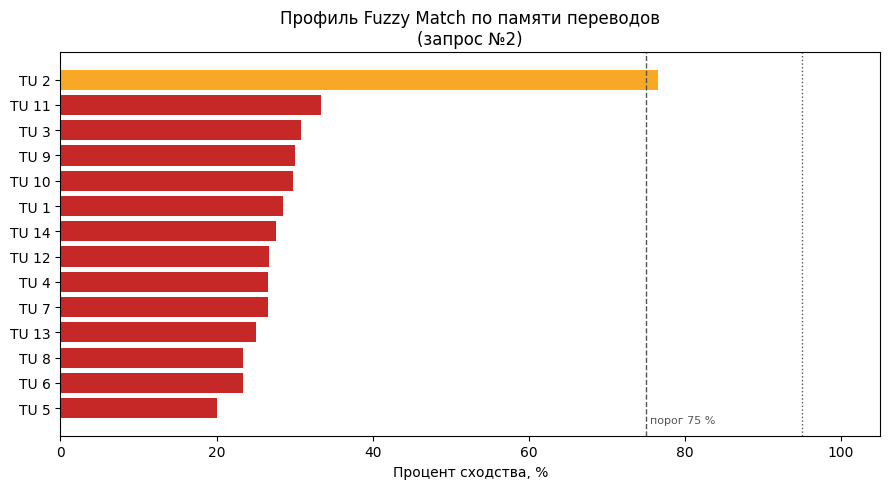

Максимум: 76.56 %   медиана: 27.20 %


In [9]:
probe = QUERIES[1]["query"]
scores = [similarity(probe, seg)["score"] for seg in tm_df["source_segment"]]
profile = (pd.DataFrame({"tuid": tm_df["tuid"], "score": scores})
           .sort_values("score", ascending=True))

colors = ["#2e7d32" if value >= 95 else "#f9a825" if value >= 75 else "#c62828"
          for value in profile["score"]]

figure, axes = plt.subplots(figsize=(9, 5))
axes.barh([f"TU {tuid}" for tuid in profile["tuid"]], profile["score"], color=colors)
axes.axvline(75, color="#555555", linestyle="--", linewidth=1)
axes.axvline(95, color="#555555", linestyle=":", linewidth=1)
axes.set_xlim(0, 105)
axes.set_xlabel("Процент сходства, %")
axes.set_title("Профиль Fuzzy Match по памяти переводов\n(запрос №2)")
axes.text(75.5, -0.6, "порог 75 %", fontsize=8, color="#555555")
figure.tight_layout()
plt.show()

print(f"Максимум: {max(scores):.2f} %   медиана: {pd.Series(scores).median():.2f} %")

## Блок 7. Интеграция глоссария: подстановка терминов (2 балла)

Терминологическая разметка выполняется по правилам, принятым в CAT-системах:

* кандидаты сортируются по убыванию длины — многословный термин
  «uncrewed aircraft system» должен сработать раньше, чем «aircraft»;
* поиск регистронезависимый, но по границам слов, чтобы «pitot» не совпал
  внутри другого слова;
* уже размеченные фрагменты повторно не обрабатываются (защита от вложенных
  подстановок).

### Пояснение к блоку 7

**Что делает блок.** Ищет в исходном предложении известные термины и добавляет рядом их переводные эквиваленты из TBX-глоссария.

**Почему термины сортируются по длине.** Если сначала заменить короткий термин, он может разрушить более длинное словосочетание. Поэтому многословные единицы обрабатываются раньше.

**Почему используются границы слов.** Регулярное выражение `(?<!\w)...(?!\w)` предотвращает случайное совпадение термина как части другого слова.

**Зачем нужны временные маркеры `\x00...\x00`.** Уже выполненная подстановка временно защищается от повторной обработки. После завершения поиска маркеры заменяются на готовые фрагменты.

**Что показывает `glossary_coverage()`.** Функция не изменяет текст, а возвращает список найденных терминов. Это позволяет измерять терминологическое покрытие сегмента.

**Педагогический акцент.** Блок демонстрирует принцип контролируемой терминологии: автоматизация помогает не «переводить вместо человека», а снижать риск непоследовательного употребления специальных терминов.


In [10]:
def apply_term_glossary(text: str, glossary_df: pd.DataFrame,
                        template: str = "{source} [{target}]") -> str:
    """Разметить исходный текст переводными эквивалентами из глоссария.

    Args:
        text: исходный сегмент на языке оригинала.
        glossary_df: таблица глоссария (результат :func:`parse_tbx`) с колонками
            ``source_term`` и ``target_term``.
        template: шаблон подстановки; поля ``{source}`` и ``{target}``.

    Returns:
        Текст, в котором найденные термины заменены по шаблону. Порядок слов и
        регистр исходного текста сохраняются.
    """
    if glossary_df.empty or not text:
        return text

    pairs = sorted(
        zip(glossary_df["source_term"], glossary_df["target_term"]),
        key=lambda pair: len(pair[0]), reverse=True,
    )

    protected: List[str] = []

    def _store(replacement: str) -> str:
        protected.append(replacement)
        return f"\x00{len(protected) - 1}\x00"

    result = text
    for source_term, target_term in pairs:
        pattern = re.compile(rf"(?<!\w){re.escape(source_term)}(?!\w)", re.IGNORECASE)
        result = pattern.sub(
            lambda match: _store(template.format(source=match.group(0), target=target_term)),
            result,
        )

    return re.sub(r"\x00(\d+)\x00", lambda m: protected[int(m.group(1))], result)


def glossary_coverage(text: str, glossary_df: pd.DataFrame) -> List[str]:
    """Вернуть список терминов глоссария, найденных в тексте."""
    found: List[str] = []
    for term in glossary_df["source_term"]:
        if re.search(rf"(?<!\w){re.escape(term)}(?!\w)", text, re.IGNORECASE):
            found.append(term)
    return found


DEMO_SEGMENTS = [
    "The uncrewed aircraft system transmits the payload status over the telemetry link.",
    "A frozen pitot tube and a failed inertial measurement unit disable the autopilot.",
    "The ground control station recalculates the waypoint and the angle of attack limit.",
]

for segment in DEMO_SEGMENTS:
    print("-" * 100)
    print(f"Исходный сегмент : {segment}")
    print(f"С подстановкой   : {apply_term_glossary(segment, glossary_df)}")
    print(f"Найдено терминов : {len(glossary_coverage(segment, glossary_df))} "
          f"-> {glossary_coverage(segment, glossary_df)}")

----------------------------------------------------------------------------------------------------
Исходный сегмент : The uncrewed aircraft system transmits the payload status over the telemetry link.
С подстановкой   : The uncrewed aircraft system [беспилотная авиационная система] transmits the payload [целевая нагрузка] status over the telemetry link [канал телеметрии].
Найдено терминов : 3 -> ['uncrewed aircraft system', 'payload', 'telemetry link']
----------------------------------------------------------------------------------------------------
Исходный сегмент : A frozen pitot tube and a failed inertial measurement unit disable the autopilot.
С подстановкой   : A frozen pitot tube [приёмник воздушного давления] and a failed inertial measurement unit [инерциальный измерительный блок] disable the autopilot [автопилот].
Найдено терминов : 3 -> ['pitot tube', 'inertial measurement unit', 'autopilot']
--------------------------------------------------------------------------------

### 7.1. Симуляция работы переводчика: ТМ + глоссарий

Для каждого сегмента документа система сначала ищет совпадение в памяти
переводов; если процент ниже 75 %, сегмент передаётся переводчику с
предварительной терминологической разметкой.

### Пояснение к симуляции 7.1

Этот блок объединяет две ранее независимые технологии в единый рабочий процесс. Для каждого нового сегмента сначала выполняется поиск в TMX-памяти. Если найден подходящий кандидат, переводчику предлагается готовый или частично готовый перевод. Если совпадения нет, включается терминологическая подсказка из TBX.

Получается упрощённая модель поведения CAT-системы:

`новый сегмент → поиск в TM → оценка процента → предложение перевода или подсказка из глоссария`.

В таблице `pipeline_df` фиксируются тип совпадения, процент, предлагаемая подсказка и рекомендуемое действие. Это уже не отдельный алгоритм, а небольшой **конвейер поддержки принятия решения переводчиком**.

Для педагогической аудитории здесь полезно подчеркнуть идею человеко-машинного взаимодействия: система автоматизирует рутинный поиск и предлагает варианты, но окончательное решение остаётся за специалистом.


In [11]:
DOCUMENT = [
    "The operator uploads a new waypoint to the autopilot.",                    # ожидается ICE
    "Before the flight the engineer checks the telemetry link quality.",        # ожидается Fuzzy
    "The gimbal keeps the payload horizon stable during aggressive manoeuvres.",  # ожидается No match
]

pipeline_rows: List[Dict[str, Any]] = []
previous_segment: Optional[str] = "Exceeding the critical angle of attack leads to a stall."

for segment in DOCUMENT:
    matches = calculate_fuzzy_match(segment, tm_df, threshold=75.0,
                                    context_before=previous_segment, top_n=1)
    if matches:
        best = matches[0]
        action = "подставить из ТМ" if best["score"] >= 95 else "отредактировать вариант из ТМ"
        pipeline_rows.append({
            "segment": segment,
            "match_type": best["match_type"],
            "score": best["score"],
            "suggestion": best["target_segment"],
            "action": action,
        })
    else:
        pipeline_rows.append({
            "segment": segment,
            "match_type": "No Match",
            "score": 0.0,
            "suggestion": apply_term_glossary(segment, glossary_df),
            "action": "перевод с нуля по глоссарию",
        })
    previous_segment = segment

pipeline_df = pd.DataFrame(pipeline_rows)
for row in pipeline_rows:
    print("=" * 100)
    print(f"Сегмент    : {row['segment']}")
    print(f"Совпадение : {row['match_type']} ({row['score']:.2f} %) -> {row['action']}")
    print(f"Подсказка  : {row['suggestion']}")

print("=" * 100)
pipeline_df[["match_type", "score", "action"]]

Сегмент    : The operator uploads a new waypoint to the autopilot.
Совпадение : ICE (101%) (100.00 %) -> подставить из ТМ
Подсказка  : Оператор загружает новую путевую точку в автопилот.
Сегмент    : Before the flight the engineer checks the telemetry link quality.
Совпадение : Fuzzy (76.56 %) -> отредактировать вариант из ТМ
Подсказка  : Перед взлётом оператор проверяет качество канала телеметрии.
Сегмент    : The gimbal keeps the payload horizon stable during aggressive manoeuvres.
Совпадение : No Match (0.00 %) -> перевод с нуля по глоссарию
Подсказка  : The gimbal [гиростабилизированный подвес] keeps the payload [целевая нагрузка] horizon stable during aggressive manoeuvres.


,match_type,score,action
0,ICE (101%),100.00,подставить из ТМ
1,Fuzzy,76.56,отредактировать вариант из ТМ
2,No Match,0.00,перевод с нуля по глоссарию


## Блок 8. Экспорт результатов для Smartcat

Smartcat импортирует глоссарии из CSV с заголовком вида
`Source (en);Target (ru);Comment` (UTF-8, разделитель — запятая или точка с
запятой). Память переводов загружается напрямую в формате `.tmx`.

Выгружаются три файла:

| Файл | Назначение |
|------|------------|
| `glossary_smartcat_v25.csv` | импорт глоссария в Smartcat |
| `tm_segments_v25.csv` | таблица параллельных сегментов для проверки |
| `fuzzy_report_v25.csv` | отчёт по найденным нечётким совпадениям |

### Пояснение к блоку 8

**Что делает блок.** Преобразует внутренние таблицы `pandas` в файлы, которые можно передать во внешнюю систему или использовать в отчёте.

**Почему используется CSV.** После сложной XML-обработки результат часто нужен в простой табличной форме. CSV хорошо подходит для обмена между Python, электронными таблицами и CAT-системами.

**Три вида экспорта имеют разные задачи.**
- `glossary_smartcat_v25.csv` — практический импорт терминов;
- `tm_segments_v25.csv` — контрольная таблица содержимого памяти переводов;
- `fuzzy_report_v25.csv` — аналитический отчёт о найденных совпадениях.

**Обратите внимание на `encoding="utf-8-sig"`.** Такая кодировка помогает корректно открывать русский текст в программах, которые ожидают BOM при чтении UTF-8.

**Результат блока.** Ноутбук не только выполняет вычисления, но и создаёт переносимые артефакты — важный этап любой прикладной работы с данными.


In [12]:
GLOSSARY_CSV = "glossary_smartcat_v25.csv"
TM_CSV = "tm_segments_v25.csv"
FUZZY_CSV = "fuzzy_report_v25.csv"

smartcat_df = pd.DataFrame({
    "Source (en)": glossary_df["source_term"],
    "Target (ru)": glossary_df["target_term"],
    "Comment": glossary_df["definition"],
})
smartcat_df.to_csv(GLOSSARY_CSV, index=False, encoding="utf-8-sig",
                   quoting=csv.QUOTE_MINIMAL)

tm_df[["tuid", "source_segment", "target_segment", "domain"]].to_csv(
    TM_CSV, index=False, encoding="utf-8-sig")

matches_df[["query", "tuid", "source_segment", "target_segment",
            "score", "lev_ratio", "token_sort_ratio", "match_type"]].to_csv(
    FUZZY_CSV, index=False, encoding="utf-8-sig")

print("Экспортированные файлы:")
for name in [TBX_PATH, TMX_PATH, GLOSSARY_CSV, TM_CSV, FUZZY_CSV]:
    print(f"  {name:<28} {os.path.getsize(name):>7} байт")

print("\nПревью glossary_smartcat_v25.csv:")
smartcat_df.head(5)

Экспортированные файлы:
  variant_25.tbx                 13981 байт
  variant_25.tmx                  6363 байт
  glossary_smartcat_v25.csv       2278 байт
  tm_segments_v25.csv             3210 байт
  fuzzy_report_v25.csv             593 байт

Превью glossary_smartcat_v25.csv:


,Source (en),Target (ru),Comment
0,flight controller,полётный контроллер,Onboard computer that stabilises the aircr...
1,uncrewed aircraft system,беспилотная авиационная система,"Aircraft, ground control station, datalink..."
2,payload,целевая нагрузка,Equipment carried to perform the mission (...
3,telemetry link,канал телеметрии,Radio channel transmitting aircraft state ...
4,pitot tube,приёмник воздушного давления,Sensor measuring total pressure to derive ...


### 8.1. Итоговая сводка по работе

### Пояснение к итоговой сводке 8.1

Сводная таблица объединяет ключевые показатели лабораторной работы: корректность TBX, число единиц TMX, количество найденных Fuzzy Match, число ICE-совпадений и количество терминологических подстановок.

Это пример **автоматической самопроверки результата**. Вместо того чтобы оценивать работу только визуально, программа формирует измеримые показатели и статусы. Такой подход полезен и в учебных заданиях: критерии оценивания можно связывать с проверяемыми результатами выполнения программы.


In [13]:
summary = pd.DataFrame([
    {"Этап": "1. Парсинг и валидация TBX", "Метрика": "термостатей",
     "Значение": report["entries"], "Статус": "OK" if report["valid"] else "ОШИБКА"},
    {"Этап": "2. Парсинг TMX", "Метрика": "единиц перевода",
     "Значение": len(tm_df), "Статус": "OK" if len(tm_df) >= 10 else "МАЛО ДАННЫХ"},
    {"Этап": "3. Fuzzy Match", "Метрика": "кандидатов выше порога",
     "Значение": len(matches_df), "Статус": "OK"},
    {"Этап": "3. ICE", "Метрика": "контекстных совпадений",
     "Значение": int((matches_df["match_type"] == "ICE (101%)").sum()), "Статус": "OK"},
    {"Этап": "4. Глоссарий", "Метрика": "терминов подставлено (демо)",
     "Значение": sum(len(glossary_coverage(s, glossary_df)) for s in DEMO_SEGMENTS),
     "Статус": "OK"},
])
print(summary.to_string(index=False))

                      Этап                     Метрика  Значение Статус
1. Парсинг и валидация TBX                 термостатей        18     OK
            2. Парсинг TMX             единиц перевода        14     OK
            3. Fuzzy Match      кандидатов выше порога         2     OK
                    3. ICE      контекстных совпадений         1     OK
              4. Глоссарий терминов подставлено (демо)         9     OK


## Выводы

1. Стандарт **TBX** (ISO 30042) описывает понятие как `termEntry` с одной
   `langSet` на язык; допускаются две формы записи термина — компактная `tig`
   и расширенная `ntig/termGrp`, поэтому надёжный парсер обязан обходить
   `langSet` целиком, а не рассчитывать на фиксированный путь.
2. Стандарт **TMX 1.4b** хранит выравненные сегменты как `tu → tuv → seg`;
   язык варианта задаётся атрибутом `xml:lang`, который в парсере раскрывается
   в полное имя с пространством имён XML.
3. Расстояние Левенштейна даёт базовую метрику Fuzzy Match, но чувствительно к
   перестановкам слов; комбинация с **Token Sort Ratio** повышает полноту
   выдачи без потери точности.
4. **ICE (In-Context Exact Match)** отличается от обычного 100 %-совпадения
   учётом соседних сегментов — только он позволяет подставлять перевод без
   проверки редактором.
5. Автоматическая терминологическая разметка требует сортировки терминов по
   убыванию длины и защиты уже размеченных фрагментов, иначе многословные
   термины разрушаются вложенными подстановками.

### Методический итог для преподавателя

Лабораторная работа связывает три уровня понимания:

1. **Форматы данных** — студент различает TBX, TMX и CSV и понимает их назначение.
2. **Алгоритмы обработки** — студент видит парсинг XML, нормализацию текста, расстояние Левенштейна, ранжирование и регулярные выражения.
3. **Прикладной сценарий** — отдельные алгоритмы объединяются в модель CAT-системы, где память переводов и терминологическая база совместно поддерживают работу переводчика.

Для педагогической аудитории особенно важно обсуждать не только программную реализацию, но и **дидактический смысл автоматизации**: какие действия пользователя снимает система, какие решения остаются за человеком, какие ошибки можно обнаружить автоматически и какие метрики позволяют оценить качество результата.
